<a href="https://colab.research.google.com/github/raushankumar018/MLOps-Lab/blob/main/Lab-01-Skill-Gap-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
# Cell 2: Upload Dataset
uploaded = files.upload()

Saving skill_gap_dataset.csv to skill_gap_dataset.csv


In [ ]:
# Cell 3: Load Dataset
df = pd.read_csv("skill_gap_dataset.csv", encoding="cp1252")

df.head()

,Skill Name,Curriculum Coverage (0–5),Industry Demand (0–5),Job Frequency (0–10),Expert Importance (0–5),Gap_Status
0,C Programming,5,3,5,3,Aligned
1,C++,5,4,7,4,Aligned
2,Java,5,5,10,5,Aligned
3,Python,4,5,10,5,Aligned
4,JavaScript,4,5,10,5,Aligned


In [ ]:
# Cell 4: Dataset Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (104, 6)


In [ ]:
# Cell 5: Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Skill Name                 104 non-null    object
 1   Curriculum Coverage (0–5)  104 non-null    int64 
 2   Industry Demand (0–5)      104 non-null    int64 
 3   Job Frequency (0–10)       104 non-null    int64 
 4   Expert Importance (0–5)    104 non-null    int64 
 5   Gap_Status                 104 non-null    object
dtypes: int64(4), object(2)
memory usage: 5.0+ KB


In [ ]:
# Cell 6: Check Missing Values
print(df.isnull().sum())

Skill Name                   0
Curriculum Coverage (0–5)    0
Industry Demand (0–5)        0
Job Frequency (0–10)         0
Expert Importance (0–5)      0
Gap_Status                   0
dtype: int64


In [ ]:
# Cell 7: Check Duplicate Values
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [ ]:
# Cell 8: Display Column Names
print(df.columns)

Index(['Skill Name', 'Curriculum Coverage (0–5)', 'Industry Demand (0–5)',
       'Job Frequency (0–10)', 'Expert Importance (0–5)', 'Gap_Status'],
      dtype='object')


In [ ]:
# Cell 9: Encode Categorical Columns
# Encode Skill Name
skill_encoder = LabelEncoder()
df["Skill Name"] = skill_encoder.fit_transform(df["Skill Name"])

# Encode Target Column
gap_encoder = LabelEncoder()
df["Gap_Status"] = gap_encoder.fit_transform(df["Gap_Status"])

df.head()

,Skill Name,Curriculum Coverage (0–5),Industry Demand (0–5),Job Frequency (0–10),Expert Importance (0–5),Gap_Status
0,15,5,3,5,3,0
1,16,5,4,7,4,0
2,54,5,5,10,5,0
3,80,4,5,10,5,0
4,55,4,5,10,5,0


In [ ]:
# Cell 10: Separate Features and Target
X = df.drop("Gap_Status", axis=1)

y = df["Gap_Status"]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

Input Shape : (104, 5)
Output Shape: (104,)


In [ ]:
# Cell 11: Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (83, 5)
Testing Data : (21, 5)


In [ ]:
# Cell 12: Train Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [ ]:
# Cell 13: Make Predictions
y_pred = model.predict(X_test)

print(y_pred)

[1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 1 1 1]


In [ ]:
# Cell 14: Model Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", round(accuracy * 100, 2), "%")

Accuracy = 100.0 %


In [ ]:
# Cell 15: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")

print(cm)

Confusion Matrix
[[ 6  0]
 [ 0 15]]


In [ ]:
# Cell 16: Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        15

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



In [ ]:
# Cell 17: Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                     Feature  Importance
1  Curriculum Coverage (0–5)    0.599905
3       Job Frequency (0–10)    0.152856
2      Industry Demand (0–5)    0.088255
4    Expert Importance (0–5)    0.079698
0                 Skill Name    0.079287


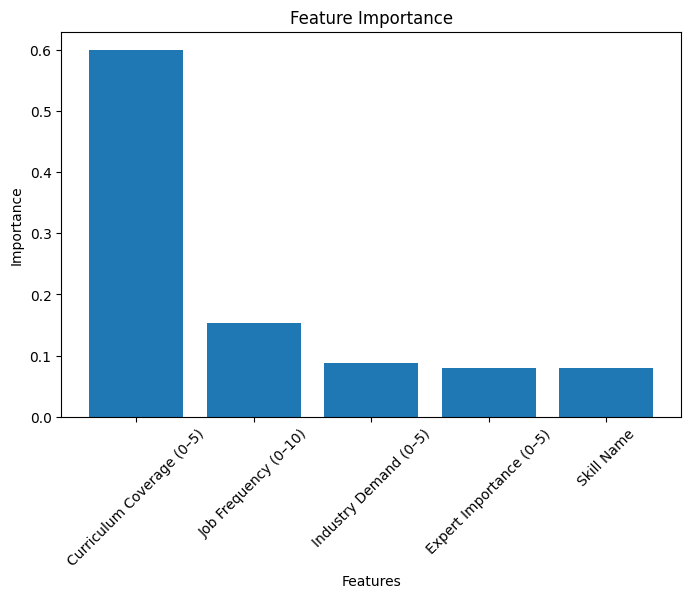

In [ ]:
# Cell 18: Plot Feature Importance
plt.figure(figsize=(8,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Cell 19: Predict a New Skill
new_skill = pd.DataFrame({
    "Skill Name": [10],
    "Curriculum Coverage (0–5)": [3],
    "Industry Demand (0–5)": [5],
    "Job Frequency (0–10)": [8],
    "Expert Importance (0–5)": [5]
})

prediction = model.predict(new_skill)

print("Predicted Class:", prediction[0])

Predicted Class: 1


In [ ]:
# Cell 20: Convert Prediction to Original Label
print("Prediction:")

print(gap_encoder.inverse_transform(prediction)[0])

Prediction:
Gap


In [ ]:
# Cell 21: Display Actual vs Predicted
result = pd.DataFrame({
    "Actual": gap_encoder.inverse_transform(y_test),
    "Predicted": gap_encoder.inverse_transform(y_pred)
})

result.head(10)

,Actual,Predicted
0,Gap,Gap
1,Aligned,Aligned
2,Gap,Gap
3,Gap,Gap
4,Gap,Gap
5,Gap,Gap
6,Gap,Gap
7,Gap,Gap
8,Aligned,Aligned
9,Aligned,Aligned


In [ ]:
# Cell 22: Save the Trained Model (Optional)
import joblib

joblib.dump(model, "skill_gap_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
